In [1]:
import scqubits
import numpy as np
from scipy.optimize import minimize


import sys
original_sys_path = sys.path.copy()
sys.path.append('../')
from utils import *
# sys.path = original_sys_path

In [2]:
EJ = 2.65
EC = 0.6
EL = 0.13

qubit_level = 30


def get_shift_accurate(ele,omega_i, omega_j, omega_r):
    return abs(ele)**2 / (omega_j-omega_i-omega_r) - abs(ele)**2 / (omega_i-omega_j-omega_r)


qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=qubit_level)
evals = qbt.eigenvals(qubit_level)
elements = qbt.matrixelement_table('n_operator',evals_count = qubit_level)

def shift_diff(x):
    Er = x[0]

    shifts_from_one = [get_shift_accurate(elements[1,ql2],evals[ql2],evals[1],Er) for ql2 in range(qubit_level)] 
    shift_from_one = sum(shifts_from_one)
    shifts_from_two = [get_shift_accurate(elements[2,ql2],evals[ql2],evals[2],Er) for ql2 in range(qubit_level)] 
    shift_from_two = sum(shifts_from_two)
    return abs(shift_from_one-shift_from_two)

initial_guess = [7.15]

# Call the optimizer
result = minimize(shift_diff, initial_guess, method='Nelder-Mead')

print("Result:", result)
print("Optimal solution:", result.x)
print("Objective value:", result.fun)


Result:        message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 2.177946977592604e-06
             x: [ 7.174e+00]
           nit: 14
          nfev: 29
 final_simplex: (array([[ 7.174e+00],
                       [ 7.174e+00]]), array([ 2.178e-06,  6.172e-06]))
Optimal solution: [7.17391479]
Objective value: 2.177946977592604e-06



qubit 12 transition and differential stark at different oscillator level
qbt freq at osc 0:	0.021615343592458425
qbt freq at osc 1:	0.02162, 	diff to at osc ground 0.00000, 0.0053% diff
qbt freq at osc 2:	0.02162, 	diff to at osc ground 0.00000, 0.0132% diff
qbt freq at osc 3:	0.02162, 	diff to at osc ground 0.00001, 0.0238% diff
qbt freq at osc 4:	0.02162, 	diff to at osc ground 0.00001, 0.0369% diff
qbt freq at osc 5:	0.02163, 	diff to at osc ground 0.00001, 0.0526% diff
qbt freq at osc 6:	0.02163, 	diff to at osc ground 0.00002, 0.0708% diff
qbt freq at osc 7:	0.02164, 	diff to at osc ground 0.00002, 0.0915% diff
qbt freq at osc 8:	0.02164, 	diff to at osc ground 0.00002, 0.1147% diff
qbt freq at osc 9:	0.02165, 	diff to at osc ground 0.00003, 0.1403% diff
qbt freq at osc 10:	0.02165, 	diff to at osc ground 0.00004, 0.1683% diff
qbt freq at osc 11:	0.02166, 	diff to at osc ground 0.00004, 0.1987% diff
qbt freq at osc 12:	0.02167, 	diff to at osc ground 0.00005, 0.2315% diff
qbt fre

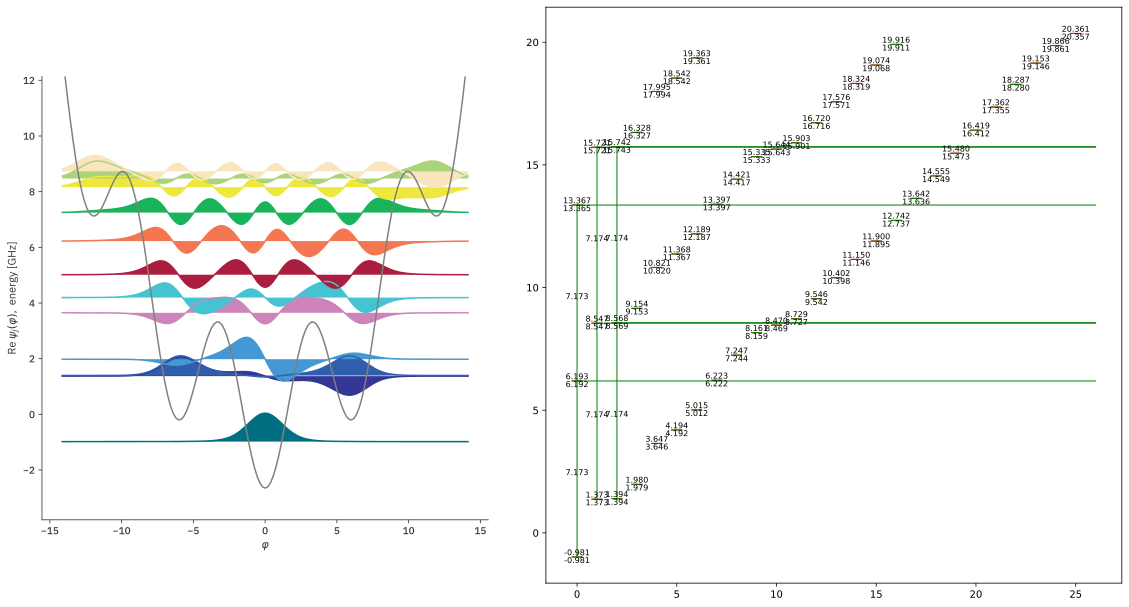

In [4]:
max_ol = 50
max_ql = 30
# g = abs(evals[7]-evals[0]-result.x[0])
# print(f"g:{g}")
g = 0.11
system = fluxonium_oscillator_system(
    EJ = EJ,
    EC = EC,
    EL = EL,
    Er = result.x[0],
    g_strength = g,
    qubit_level = max_ql,
    osc_level = max_ol,
    kappa = 0.004,
    products_to_keep=[[ql, ol] for ql in range(max_ql) for ol in range(max_ol) ],
    computaional_states= '1,2'
    )


energies=  system.hilbertspace.eigenvals(max_ql * max_ol)
def dressed_ener(ql,ol):
    return energies[system.product_to_dressed[(ql,ol)]]
def print_stats():
    print(f"\nqubit 12 transition and differential stark at different oscillator level")
    print(f"qbt freq at osc {0}:\t{(dressed_ener(2,0)-dressed_ener(1,0))}")
    ground_freq = dressed_ener(2,0)-dressed_ener(1,0)
    for i in range(1,max_ol-1):
        freq = dressed_ener(2,i)-dressed_ener(1,i)
        print(f"qbt freq at osc {i}:\t{freq:.5f}, \tdiff to at osc ground {freq - ground_freq:.5f}, {abs(freq - ground_freq)/ground_freq*100:.4f}% diff")

    print(f"\noscillator freq at qubit level:\t0 \t 1 \t 2 \t 3:")
    print(f"oscillator transition 0-1: \t{dressed_ener(0,1)-dressed_ener(0,0):.5f}\t{dressed_ener(1,1)-dressed_ener(1,0):.5f}\t{dressed_ener(2,1)-dressed_ener(2,0):.5f}\t{dressed_ener(3,1)-dressed_ener(3,0):.5f}")
    for i in range(1,max_ol-1):
        print(f"oscillator transition {i}-{i+1}: \t{dressed_ener(0,i+1)-dressed_ener(0,i):.5f}\t{dressed_ener(1,i+1)-dressed_ener(1,i):.5f}\t{dressed_ener(2,i+1)-dressed_ener(2,i):.5f}\t{dressed_ener(3,i+1)-dressed_ener(3,i):.5f}  oscillator frequency coupled to qubit 0th state compared to 00-01 (non-linearity): {(dressed_ener(0,i+1)-dressed_ener(0,i))  -(dressed_ener(0,1)-dressed_ener(0,0))}")

    print(f"")
    print(f"10-11: {(dressed_ener(1,1)-dressed_ener(1,0)):.4f}, diff to 00-01: {abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(1,1)-dressed_ener(1,0)))}")
    print(f"20-21: {(dressed_ener(2,1)-dressed_ener(2,0)):.4f}, diff to 00-01: {abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(2,1)-dressed_ener(2,0)))}")
print_stats()
plot_specturum(system.qbt, system.osc, system.hilbertspace,num_levels = 50)

(<Figure size 1000x500 with 3 Axes>, (<Axes3D: >, <Axes: >))

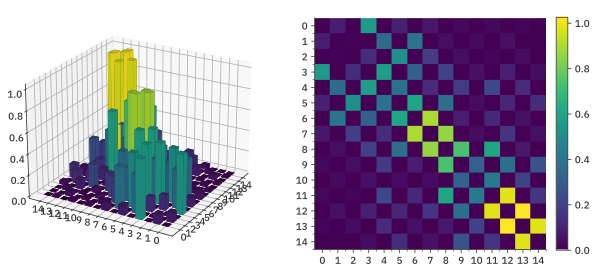

In [95]:
system.qbt.plot_matrixelements(operator = 'n_operator',evals_count = 15)

In [97]:
elements = system.qbt.matrixelement_table(operator="n_operator",evals_count=15)

for i in [1,3,5,7,9,11,13]:
    print(f"{i}-0: {elements[0,i]}")

1-0: 0.0865397614576715j
3-0: 0.5596610034395441j
5-0: -0.08845727677113235j
7-0: -0.06743576672587895j
9-0: -0.022174241970136063j
11-0: 0.02347037669455564j
13-0: -0.013243825690125745j
